In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_extract_features(filepath):
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            r = json.loads(line)
            
            rho = np.array(r.get('rho', []))
            load = np.array(r.get('load_p', []))
            gen = np.array(r.get('gen_p', []))
            
            if len(rho) == 0: continue
            
            # Forcing strict python scalars (float/int/str) to prevent Pandas hashing errors
            features = {
                'label': str(r['label']),
                'max_rho': float(np.max(rho)),
                'mean_rho': float(np.mean(rho)),
                'std_rho': float(np.std(rho)),
                'rho_above_90_pct': int(np.sum(rho > 0.90)), 
                'rho_above_100_pct': int(np.sum(rho >= 1.0)), 
                'total_load': float(np.sum(load)),
                'total_gen': float(np.sum(gen)),
                'fault_loc': int(r['fault_loc']) if r.get('fault_loc') is not None else -1
            }
            data.append(features)
            
    # Explicitly ensure we return a Pandas DataFrame, not a dict or list
    df = pd.DataFrame(data)
    return df
df = load_and_extract_features("data/grid_dataset_neurips2020_smoke.jsonl")

In [2]:
# 1. Verify it's actually a Pandas DataFrame
print(f"Type of df: {type(df)}")

# 2. Verify the columns contain basic data types, not objects/arrays
print(df.dtypes)

# 3. Test the boolean mask manually
mask = (df['label'] == 'normal') & (df['max_rho'] >= 1.0)
print(f"Type of mask: {type(mask)}")

Type of df: <class 'pandas.core.frame.DataFrame'>
label                 object
max_rho              float64
mean_rho             float64
std_rho              float64
rho_above_90_pct       int64
rho_above_100_pct      int64
total_load           float64
total_gen            float64
fault_loc              int64
dtype: object
Type of mask: <class 'pandas.core.series.Series'>


In [3]:
print(df['label'].value_counts())

label
normal       162750
line_trip    103000
overload      21372
cascade       12878
Name: count, dtype: int64


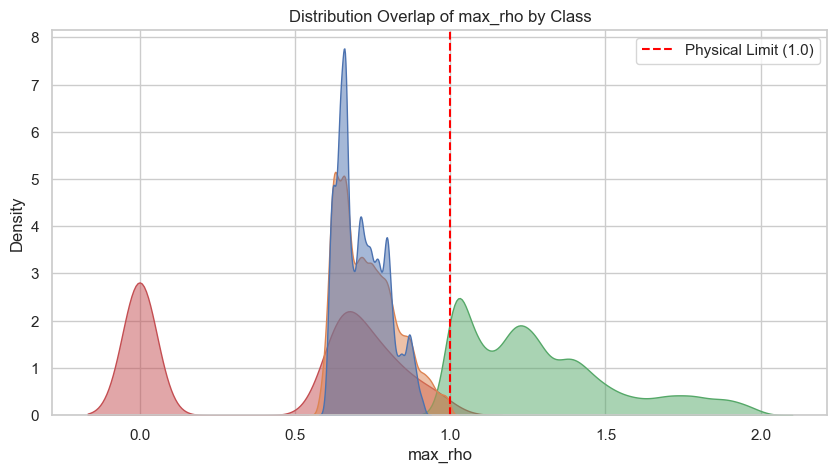

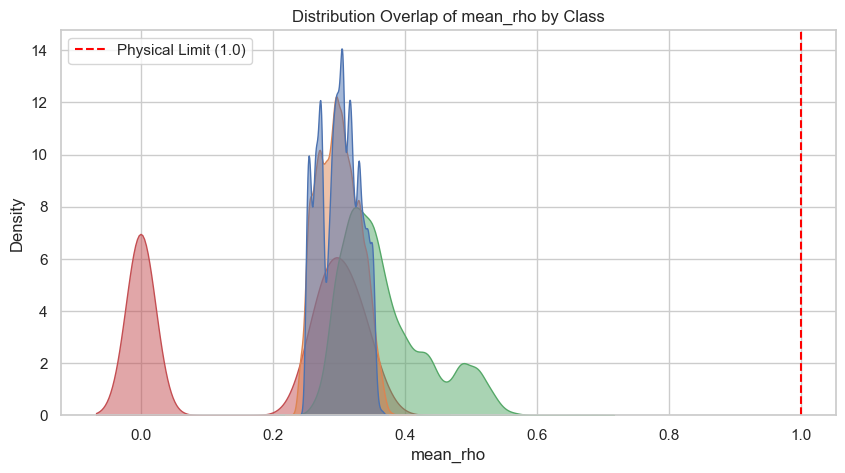

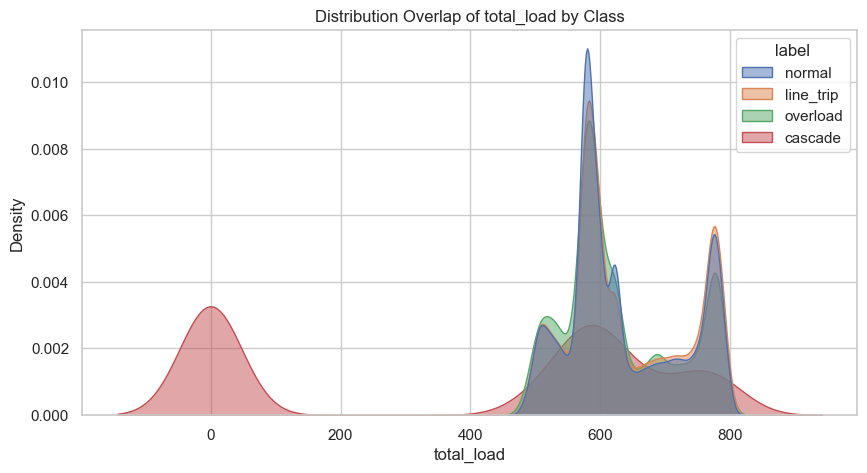

In [4]:
def plot_feature_distributions(df, feature_cols=['max_rho', 'mean_rho', 'total_load']):
    """
    Plots Kernel Density Estimates for given features, colored by label.
    High overlap in these plots explains poor F1 scores.
    """
    sns.set_theme(style="whitegrid")
    
    for feature in feature_cols:
        plt.figure(figsize=(10, 5))
        
        # KDE plot shows the shape of the distribution
        sns.kdeplot(data=df, x=feature, hue='label', common_norm=False, fill=True, alpha=0.5)
        
        plt.title(f'Distribution Overlap of {feature} by Class')
        plt.xlabel(feature)
        plt.ylabel('Density')
        
        # Add a vertical line at 1.0 for rho features to see physical limits
        if 'rho' in feature:
            plt.axvline(x=1.0, color='red', linestyle='--', label='Physical Limit (1.0)')
            plt.legend()
            
        plt.show()

# Usage:
plot_feature_distributions(df)

In [5]:
def find_contradictory_labels_safe(df):
    """
    Safely identifies records where the physical data contradicts the label,
    with protections against missing classes and division by zero.
    """
    print("--- Checking for Contradictory Labels ---")
    
    # Ensure labels are lowercase strings to prevent mismatch errors
    df['label_lower'] = df['label'].astype(str).str.lower()
    
    def check_overlap(label_name, condition, description):
        # Isolate the specific class
        class_df = df[df['label_lower'] == label_name]
        total_class = len(class_df)
        
        # Prevent ZeroDivisionError if the class doesn't exist
        if total_class == 0:
            print(f"[{label_name.upper()}] SKIPPED: 0 records found for this class.")
            return
            
        # Apply the physical condition check
        overlap_df = class_df[condition(class_df)]
        count = len(overlap_df)
        pct = count / total_class
        print(f"[{label_name.upper()}] {description}: {count} out of {total_class} ({pct:.2%})")

    # 1. Normal states that have lines operating at or above 100% capacity
    check_overlap('normal', lambda x: x['max_rho'] >= 1.0, "States with max_rho >= 1.0")
    
    # 2. Line trips that lack high capacity usage (look like normal states)
    # NOTE: Change 'line_trip' here if Step 1 reveals a different spelling!
    check_overlap('line_trip', lambda x: x['max_rho'] < 0.85, "States with max_rho < 0.85") 
    
    # 3. Overload states where no line is actually overloaded
    check_overlap('overload', lambda x: x['max_rho'] < 1.0, "States with max_rho < 1.0")

# Usage:
find_contradictory_labels_safe(df)

--- Checking for Contradictory Labels ---
[NORMAL] States with max_rho >= 1.0: 0 out of 162750 (0.00%)
[LINE_TRIP] States with max_rho < 0.85: 89150 out of 103000 (86.55%)
[OVERLOAD] States with max_rho < 1.0: 0 out of 21372 (0.00%)


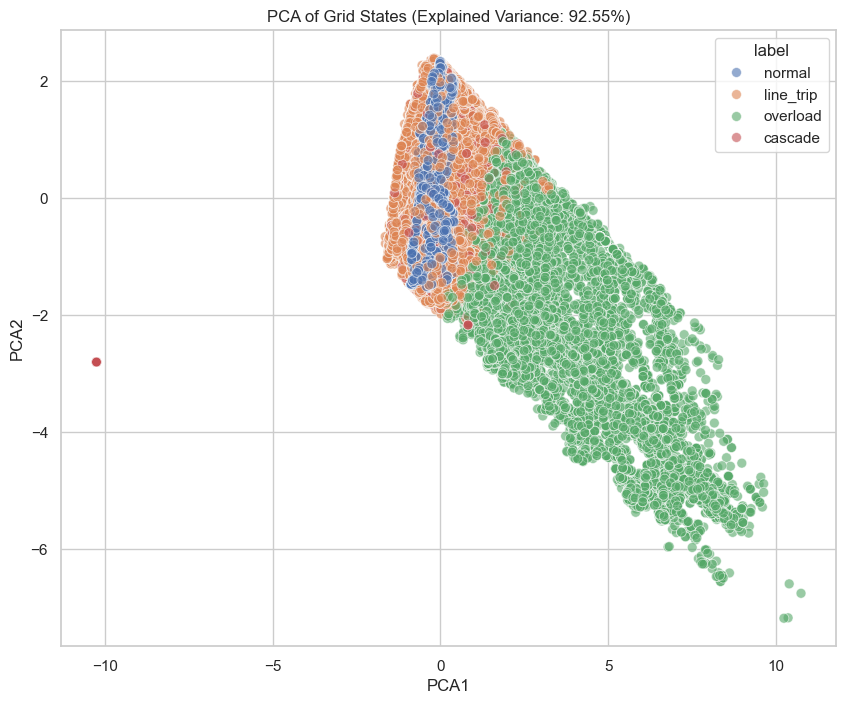

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def plot_pca_clusters(df):
    """
    Projects the features into 2D space to visualize class separability.
    """
    # Select numeric features for clustering
    features = ['max_rho', 'mean_rho', 'std_rho', 'total_load', 'total_gen']
    X = df[features].values
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Apply PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # Plot
    df_pca = pd.DataFrame({'PCA1': X_pca[:, 0], 'PCA2': X_pca[:, 1], 'label': df['label']})
    
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='label', alpha=0.6, s=50)
    plt.title(f'PCA of Grid States (Explained Variance: {sum(pca.explained_variance_ratio_):.2%})')
    plt.show()

# Usage:
plot_pca_clusters(df)